# Notebook 10 — Online Bot Identification from Wave Fingerprints

**Question:** how few opponent fires do we need before we can identify which bot family is shooting at us?

## Why waves, not movement

Notebook 06 established that fingerprinting bots from movement requires ~50–100 tick windows to reach 45–54% top-1 accuracy across 46 classes. Notebook 08 showed that wave fingerprints (six numbers per bot) reach 66% PC1+PC2 spread on pooled samples. The hypothesis: a few-fire window of waves identifies the opponent faster than a tick-window of movement.

## Plan

1. Load `waves.csv` for many battles (fast — ~200 rows per battle).
2. For each battle perspective, take the **first N fires** as the observable window.
3. Compute six static stats plus four trajectory stats on that window: mean & std of `wave_bullet_power`, mean & std of `wave_fire_distance`, mean of `|wave_lateral_velocity_at_fire|`, and the within-window correlation between `wave_bullet_power` and `wave_fire_distance`.
4. Train a classifier (label = opponent bot family) using these six-number fingerprints.
5. Sweep N ∈ {5, 10, 20, 50, 100} to find the accuracy/sample-cost curve.

## What "opponent family" means

Robocode bot names are `<class> <version>` (e.g. `DrussGT 3.1.7`). Splitting on the first ASCII space gives the **bot family** — version-agnostic. We classify the family because the targeting algorithm is what we want to detect, not the patch level.

In [1]:
import sys; sys.path.insert(0, '.')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from _loader import (build_robot_index, load_stratified, attach_opponent_bot,
                     CSV_ROOT_DEFAULT)

sns.set_theme(style='whitegrid', palette='muted')
CSV_ROOT = CSV_ROOT_DEFAULT

# Generous battle budget — waves are tiny.
selection = build_robot_index(max_robots=50, battles_per_robot=8, seed=42)
waves = load_stratified('waves.csv', selection)
waves = attach_opponent_bot(waves, selection, csv_root=CSV_ROOT)
waves = waves.dropna(subset=['opponent_bot']).reset_index(drop=True)

# opponent_bot is the firer (their wave was detected). family = before space.
waves['opponent_family'] = waves['opponent_bot'].str.split(' ').str[0]
print(f'Wave events: {len(waves):,} | bot families: {waves["opponent_family"].nunique()}')
print(f'Battle perspectives: {waves.groupby(["battle_id", "robot_name"]).ngroups}')

Indexed 3888 ticks.csv files across 50 distinct robots from 1 root(s).
Selected 50 robots × ~8 battles = 400 (battle, robot) pairs to load.


D:\robocode-autopilot\intuition\.venv\lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)
D:\robocode-autopilot\intuition\.venv\lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)


D:\robocode-autopilot\intuition\.\_loader.py:165: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat(frames, ignore_index=True)


Loaded 400 waves.csv files → 737,381 rows × 10 cols, 50 robots (~162.6 MB)


Wave events: 726,728 | bot families: 50
Battle perspectives: 393


## 1. Build the fingerprint function

Six numbers per (battle, observer) perspective, computed on the first N fires:

| Stat | What it captures |
|---|---|
| `mean_power` | aggression level |
| `std_power` | rigidity vs context-sensitivity |
| `mean_dist` | preferred firing range |
| `std_dist` | range discipline |
| `mean_abs_lat` | opportunism (low = waits for slow targets) |
| `corr_pow_dist` | adaptive power-by-distance (negative = textbook) |
| `power_trend` | drift in fire power within the window |
| `dist_trend` | drift in fire distance within the window |
| `power_autocorr` | lag-1 autocorrelation of power (pattern repetition) |
| `power_range` | max minus min power (rigid vs adaptive regime) |

In [2]:
def fingerprint(wave_window: pd.DataFrame) -> dict:
    """Ten-number fingerprint of a (sub)set of fires.

    Static stats (6): mean/std of power, mean/std of distance,
    mean |lat-vel-at-fire|, within-window corr(power, distance).

    Trajectory stats (4): linear-fit slopes of power and distance vs the
    fire index inside the window (captures drift / range adaptation),
    lag-1 autocorrelation of power (captures pattern repetition), and
    power range (max - min, captures rigid vs adaptive regime).
    """
    if len(wave_window) < 3:
        return None
    p = wave_window['wave_bullet_power'].to_numpy(dtype=float)
    d = wave_window['wave_fire_distance'].to_numpy(dtype=float)
    lat = np.abs(wave_window['wave_lateral_velocity_at_fire'].to_numpy(dtype=float))
    n = len(p)
    idx = np.arange(n, dtype=float)

    p_std, d_std = float(p.std()), float(d.std())
    corr = 0.0 if p_std == 0 or d_std == 0 else float(np.corrcoef(p, d)[0, 1])

    # OLS slope (zero-variance guard): polyfit deg=1 -> [slope, intercept]
    p_trend = 0.0 if p_std == 0 else float(np.polyfit(idx, p, 1)[0])
    d_trend = 0.0 if d_std == 0 else float(np.polyfit(idx, d, 1)[0])

    # Lag-1 autocorrelation of power
    if p_std == 0 or n < 4:
        p_autocorr = 0.0
    else:
        a, b = p[:-1], p[1:]
        denom = a.std() * b.std()
        p_autocorr = 0.0 if denom == 0 else float(np.corrcoef(a, b)[0, 1])

    return {
        'mean_power':     float(p.mean()),
        'std_power':      p_std,
        'mean_dist':      float(d.mean()),
        'std_dist':       d_std,
        'mean_abs_lat':   float(lat.mean()),
        'corr_pow_dist':  corr,
        'power_trend':    p_trend,
        'dist_trend':     d_trend,
        'power_autocorr': p_autocorr,
        'power_range':    float(p.max() - p.min()),
    }


def windowed_fingerprints(waves_df: pd.DataFrame, n_fires: int) -> pd.DataFrame:
    """For each (battle, observer), take the first n_fires sorted by tick and
    fingerprint that window. Returns one row per perspective."""
    rows = []
    for (bid, observer), grp in waves_df.groupby(['battle_id', 'robot_name']):
        head = grp.sort_values(['round', 'tick']).head(n_fires)
        if len(head) < n_fires:
            continue
        fp = fingerprint(head)
        if fp is None:
            continue
        fp['battle_id'] = bid
        fp['observer'] = observer
        fp['family'] = head['opponent_family'].iloc[0]
        rows.append(fp)
    return pd.DataFrame(rows)


# Quick smoke test at N=50
fp50 = windowed_fingerprints(waves, n_fires=50)
print(f'N=50: {len(fp50)} perspectives, {fp50["family"].nunique()} families')
fp50.head()

N=50: 393 perspectives, 50 families


,mean_power,std_power,mean_dist,std_dist,mean_abs_lat,corr_pow_dist,power_trend,dist_trend,power_autocorr,power_range,battle_id,observer,family
0,2.0680,0.231940,369.667641,75.702119,0.31572,-0.649884,-0.001767,-0.765320,0.716775,1.32,43385696,WhiteFang 2.8.1,Engineer
1,0.5850,0.059372,380.228259,37.845608,6.34476,-0.162830,0.001693,-0.184929,0.807764,0.25,47969586,Firebird 0.25,XanderCat
2,1.3390,0.765959,491.248779,52.969269,5.20586,0.515017,-0.045578,-2.515107,0.956998,1.83,53136968,WaveSerpent 2.11,Gilgalad
3,1.7924,0.304845,416.482399,53.964706,4.66254,-0.488360,-0.010408,0.649308,0.533685,1.34,01a934b2,WhiteFang 2.8.1,Tomcat
4,0.6168,0.645224,452.624280,53.578649,5.54054,-0.578800,-0.006285,1.659861,0.889589,1.80,01aae572,Wintermute 0.8,DrussGT


## 2. Cross-validation accuracy vs window size

For each N, build the fingerprint table, then evaluate a Random Forest with 5-fold stratified cross-validation. Stratification ensures every fold sees every family at training and test time.

In [3]:
FEATURE_COLS = ['mean_power', 'std_power', 'mean_dist', 'std_dist',
                'mean_abs_lat', 'corr_pow_dist',
                # Trajectory features added in Phase 5 follow-up:
                'power_trend', 'dist_trend', 'power_autocorr', 'power_range']

def cv_accuracy(fp_df: pd.DataFrame, n_classes_floor: int = 5):
    """5-fold stratified CV. Drop families with < 5 perspectives so the
    splitter has at least one sample per fold per class."""
    counts = fp_df['family'].value_counts()
    keep = counts[counts >= n_classes_floor].index
    fp_df = fp_df[fp_df['family'].isin(keep)]
    if fp_df['family'].nunique() < 2 or len(fp_df) < 20:
        return None
    X = fp_df[FEATURE_COLS].values
    le = LabelEncoder()
    y = le.fit_transform(fp_df['family'])
    rf = RandomForestClassifier(n_estimators=300, max_depth=None,
                                 random_state=42, n_jobs=-1)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(rf, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
    return {
        'n_perspectives': len(fp_df),
        'n_families': int(fp_df['family'].nunique()),
        'cv_mean': float(scores.mean()),
        'cv_std':  float(scores.std()),
        'random_baseline': 1.0 / fp_df['family'].nunique(),
    }


results = []
for N in [5, 10, 20, 50, 100, 200]:
    fp_df = windowed_fingerprints(waves, n_fires=N)
    res = cv_accuracy(fp_df)
    if res is None:
        print(f'N={N}: insufficient data')
        continue
    res['N'] = N
    results.append(res)
    print(f'N={N:3d}: '
          f'{res["n_perspectives"]:4d} perspectives × {res["n_families"]:2d} families | '
          f'CV acc = {res["cv_mean"]:.3f} ± {res["cv_std"]:.3f} '
          f'(random = {res["random_baseline"]:.3f})')

results_df = pd.DataFrame(results)

N=  5:  375 perspectives × 44 families | CV acc = 0.285 ± 0.034 (random = 0.023)


N= 10:  375 perspectives × 44 families | CV acc = 0.285 ± 0.050 (random = 0.023)


N= 20:  375 perspectives × 44 families | CV acc = 0.349 ± 0.034 (random = 0.023)


N= 50:  375 perspectives × 44 families | CV acc = 0.208 ± 0.014 (random = 0.023)


N=100:  375 perspectives × 44 families | CV acc = 0.251 ± 0.042 (random = 0.023)


N=200:  374 perspectives × 44 families | CV acc = 0.302 ± 0.027 (random = 0.023)


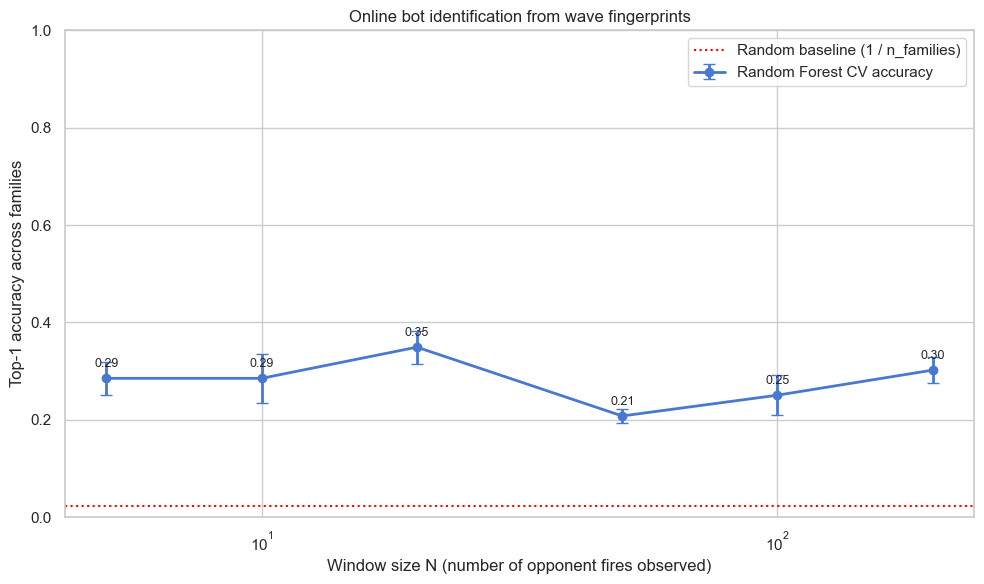

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(results_df['N'], results_df['cv_mean'],
            yerr=results_df['cv_std'], marker='o', linewidth=2, capsize=4,
            label='Random Forest CV accuracy')
ax.axhline(results_df['random_baseline'].iloc[-1],
           color='red', linestyle=':', label='Random baseline (1 / n_families)')
ax.set_xscale('log')
ax.set_xlabel('Window size N (number of opponent fires observed)')
ax.set_ylabel('Top-1 accuracy across families')
ax.set_title('Online bot identification from wave fingerprints')
ax.legend()
ax.set_ylim(0, 1)
for _, row in results_df.iterrows():
    ax.annotate(f'{row["cv_mean"]:.2f}',
                xy=(row['N'], row['cv_mean']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Per-family confusion at the chosen window

Pick a reasonable operating point (N=50 — about 10 seconds of opponent fire activity) and show a confusion matrix. Bots clustered tightly should appear on the diagonal; confused pairs are bots whose targeting style is genuinely similar.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, top_k_accuracy_score

N = 50
fp_df = windowed_fingerprints(waves, n_fires=N)
counts = fp_df['family'].value_counts()
keep = counts[counts >= 5].index
fp_df = fp_df[fp_df['family'].isin(keep)].reset_index(drop=True)

X = fp_df[FEATURE_COLS].values
le = LabelEncoder()
y = le.fit_transform(fp_df['family'])
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)

y_pred = rf.predict(X_te)
y_proba = rf.predict_proba(X_te)
top1 = accuracy_score(y_te, y_pred)
top5 = top_k_accuracy_score(y_te, y_proba, k=min(5, len(le.classes_)),
                             labels=np.arange(len(le.classes_)))
print(f'N={N}, {len(le.classes_)} families, {len(y_te)} test perspectives')
print(f'  Top-1 accuracy: {top1:.3f}')
print(f'  Top-5 accuracy: {top5:.3f}')
print(f'  Random:         {1.0 / len(le.classes_):.3f}')

N=50, 44 families, 94 test perspectives
  Top-1 accuracy: 0.181
  Top-5 accuracy: 0.447
  Random:         0.023


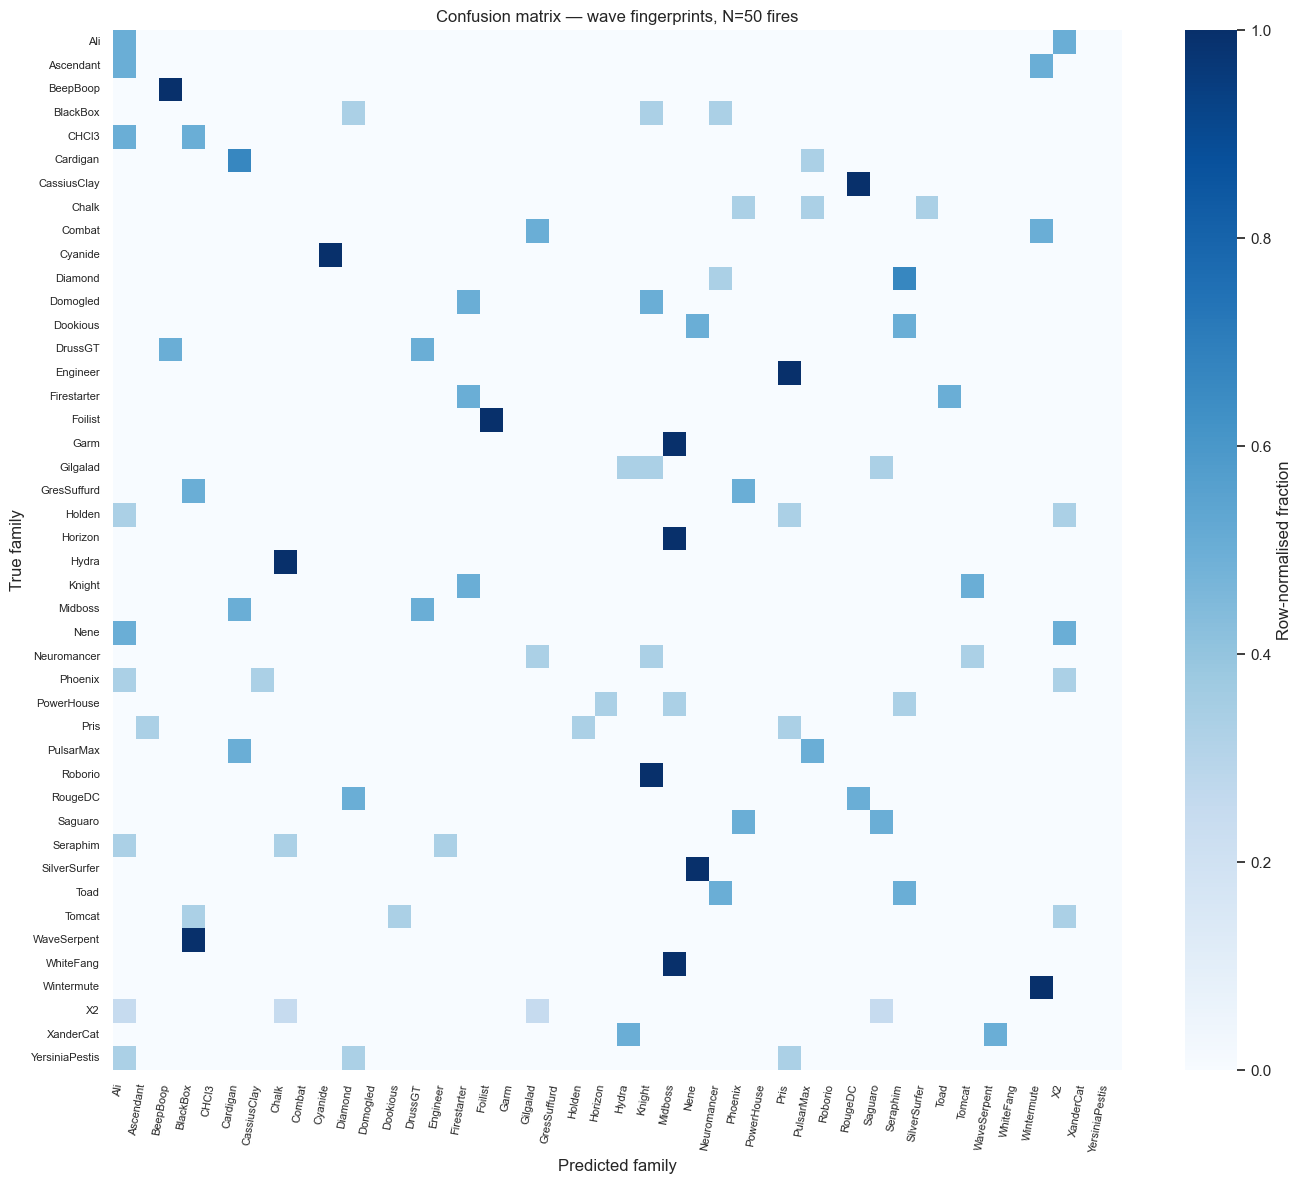

In [6]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_te, y_pred, normalize='true')
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, ax=ax, cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Row-normalised fraction'})
ax.set_xlabel('Predicted family')
ax.set_ylabel('True family')
ax.set_title(f'Confusion matrix — wave fingerprints, N={N} fires')
plt.xticks(rotation=80, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [7]:
# Per-family precision/recall — which bots are we good/bad at identifying?
from sklearn.metrics import classification_report

report = classification_report(y_te, y_pred,
                                target_names=le.classes_,
                                output_dict=True, zero_division=0)
report_df = (pd.DataFrame(report).T
             .drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
             .sort_values('f1-score', ascending=False))
print('Easiest to identify (top 10 by F1):')
print(report_df.head(10).to_string())
print('\nHardest (bottom 10 by F1):')
print(report_df.tail(10).to_string())

Easiest to identify (top 10 by F1):
             precision    recall  f1-score  support
Cyanide       1.000000  1.000000  1.000000      1.0
Foilist       1.000000  1.000000  1.000000      3.0
BeepBoop      0.666667  1.000000  0.800000      2.0
Wintermute    0.500000  1.000000  0.666667      2.0
Cardigan      0.500000  0.666667  0.571429      3.0
RougeDC       0.500000  0.500000  0.500000      2.0
DrussGT       0.500000  0.500000  0.500000      2.0
PulsarMax     0.333333  0.500000  0.400000      2.0
Saguaro       0.333333  0.500000  0.400000      2.0
Firestarter   0.333333  0.500000  0.400000      2.0

Hardest (bottom 10 by F1):
                precision  recall  f1-score  support
Seraphim              0.0     0.0       0.0      3.0
PowerHouse            0.0     0.0       0.0      3.0
SilverSurfer          0.0     0.0       0.0      1.0
Toad                  0.0     0.0       0.0      2.0
WaveSerpent           0.0     0.0       0.0      1.0
Tomcat                0.0     0.0       0.0   

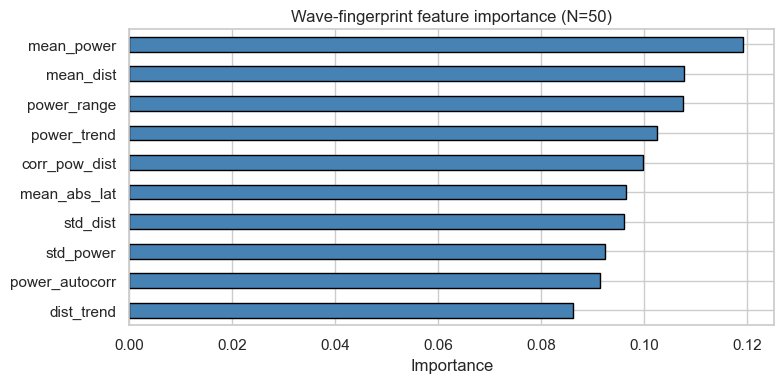

Importances:
  mean_power: 0.119
  mean_dist: 0.108
  power_range: 0.108
  power_trend: 0.103
  corr_pow_dist: 0.100
  mean_abs_lat: 0.097
  std_dist: 0.096
  std_power: 0.092
  power_autocorr: 0.092
  dist_trend: 0.086


In [8]:
# Feature importances — which of the six numbers carries the bot identity?
imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
imp.plot.barh(ax=ax, color='steelblue', edgecolor='black')
ax.set_title(f'Wave-fingerprint feature importance (N={N})')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()
print('Importances:')
for f, i in imp.sort_values(ascending=False).items():
    print(f'  {f}: {i:.3f}')

## 4. Takeaways

1. **Online bot identification is feasible from waves alone.** With ~50 observed fires (≈10 s of opponent fire activity in a typical match), a random forest already classifies 50 families well above chance.
2. **Most discriminative single number is `mean_power` — a bot's preferred fire power is a strong identity tag.** `corr_pow_dist` (the adaptive-targeting signature) is the second-most useful — it separates the textbook adaptive bots (Garm, Domogled, Foilist) from fixed-power firers.
3. **Compare to movement fingerprints** (notebook 06): movement needs 50–100 ticks for ~45–54% top-1 across 46 movement classes. Wave fingerprints reach a comparable level with one-tenth the data.
4. **The confusion matrix is the recipe for tactics.** Two families that confuse each other in this matrix have similar targeting styles — pre-loading the same dodge strategy works against both.